# FathomNet vs SQUIDLE+ — Comparative Dataset EDA

**Purpose:** Understand the structure, content, and characteristics of both databases
so we can make evidence-based decisions about which to use for training marine computer vision models,
parameterised by collection type (AUV, ROV, Diver, Towed, BRUVs, Drop Camera).

**Structure — each section's findings feed the next:**
1. Scale
2. Platform & Sensor Profile
3. Geographic, Depth & Temporal Coverage
4. Annotation Landscape
5. Image Characteristics
6. Deployment Synthesis ← built from findings 1–5

| | FathomNet | SQUIDLE+ |
|---|---|---|
| Managed by | MBARI | IMOS / ACFR |
| Access | `fathomnet-py` (pip) | REST API |
| Annotation format | Bounding boxes | Point labels (CATAMI) |

## Setup

In [40]:
!pip install fathomnet requests pandas matplotlib Pillow --quiet

In [40]:
%matplotlib inline
import json, time, warnings
from collections import Counter
from io import BytesIO

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests
import random
from PIL import Image
from fathomnet.api import boundingboxes, images, stats
from fathomnet.dto import Pageable

import re
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# ── API helpers ────────────────────────────────────────────────────────────
SQ_BASE = 'https://squidle.org'
SQ_TOKEN = None  # paste token for private campaign access

def sq_get(endpoint, params=None):
    headers = {'X-auth-token': SQ_TOKEN} if SQ_TOKEN else {}
    p = dict(params or {})
    if 'q' in p and isinstance(p['q'], dict):
        p['q'] = json.dumps(p['q'])
    r = requests.get(f'{SQ_BASE}{endpoint}', params=p, headers=headers, timeout=30)
    r.raise_for_status()
    return r.json()

def sq_pages(endpoint, params=None, max_records=2000):
    """Paginate SQUIDLE+ results up to max_records."""
    p = dict(params or {})
    p['results_per_page'] = 200
    records, page = [], 1
    while len(records) < max_records:
        p['page'] = page
        data  = sq_get(endpoint, p)
        batch = data.get('objects', [])
        if not batch: break
        records.extend(batch)
        if page >= data.get('total_pages', 1): break
        page += 1
        time.sleep(0.1)
    return records, data.get('num_results', len(records))

def fetch_image(url, timeout=10):
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        return Image.open(BytesIO(r.content)).convert('RGB')
    except Exception:
        return None


---
## 1. Scale
How large is each database?

In [41]:
# FathomNet totals — direct count endpoints
fn_total_images = images.count_all().count
fn_total_boxes  = boundingboxes.count_all().count

print(f'FathomNet total images:          {fn_total_images:>10,}')
print(f'FathomNet total bounding boxes:  {fn_total_boxes:>10,}')
print(f'Avg boxes per image:             {fn_total_boxes/fn_total_images:>10.2f}')

FathomNet total images:             448,273
FathomNet total bounding boxes:   1,082,105
Avg boxes per image:                   2.41


In [42]:
# SQUIDLE+ totals — single call to /api/stats (no sampling bias)
sq_stats        = sq_get('/api/stats')
sq_total_media  = sq_stats['datasets']['media']
sq_total_ann    = sq_stats['userdata']['annotations']
sq_total_dep    = sq_stats['datasets']['deployments']
sq_total_camp   = sq_stats['datasets']['campaigns']
sq_total_plat   = sq_stats['datasets']['platforms']

print(f'SQUIDLE+ total media (images):   {sq_total_media:>10,}')
print(f'SQUIDLE+ total annotations:      {sq_total_ann:>10,}')
print(f'SQUIDLE+ total deployments:      {sq_total_dep:>10,}')
print(f'SQUIDLE+ total campaigns:        {sq_total_camp:>10,}')
print(f'SQUIDLE+ total platforms:        {sq_total_plat:>10,}')
print(f'Avg annotations per image:       {sq_total_ann/sq_total_media:>10.2f}')

if sq_total_ann == 0:
    print('\n  WARNING: sq_total_ann = 0 — userdata.annotations reflects the authenticated')
    print('  user only. Set SQ_TOKEN to get global annotation counts.')

SQUIDLE+ total media (images):   10,489,819
SQUIDLE+ total annotations:       6,378,202
SQUIDLE+ total deployments:          25,441
SQUIDLE+ total campaigns:             1,117
SQUIDLE+ total platforms:                32
Avg annotations per image:             0.61


In [ ]:
# ── Section 1: Scale comparison chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Section 1: Scale Comparison', fontsize=13)

labels    = ['FathomNet', 'SQUIDLE+']
fn_color  = '#00bcd4'
sq_color  = '#aed581'
colors    = [fn_color, sq_color]

def _bar_labels(ax, bars, vals, fmt_fn):
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                fmt_fn(val), ha='center', va='bottom', fontsize=10)

def _fmt_count(v):
    return f'{v/1e6:.2f}M' if v >= 1e6 else f'{v/1e3:.0f}K'

# Panel 1 — Total images
img_counts = [fn_total_images, sq_total_media]
bars = axes[0].bar(labels, img_counts, color=colors, edgecolor='none', width=0.5)
_bar_labels(axes[0], bars, img_counts, _fmt_count)
axes[0].set_title('Total Images')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: _fmt_count(x)))
axes[0].grid(True, alpha=0.12, axis='y')

# Panel 2 — Total annotations
ann_counts = [fn_total_boxes, sq_total_ann]
bars2 = axes[1].bar(labels, ann_counts, color=colors, edgecolor='none', width=0.5)
_bar_labels(axes[1], bars2, ann_counts, _fmt_count)
axes[1].set_title('Total Annotations')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: _fmt_count(x)))
axes[1].grid(True, alpha=0.12, axis='y')

# Panel 3 — Annotation density
density = [fn_total_boxes / fn_total_images, sq_total_ann / sq_total_media]
bars3 = axes[2].bar(labels, density, color=colors, edgecolor='none', width=0.5)
_bar_labels(axes[2], bars3, density, lambda v: f'{v:.2f}')
axes[2].set_title('Annotation Density\n(annotations / image)')
axes[2].set_ylabel('Annotations per image')
axes[2].grid(True, alpha=0.12, axis='y')

plt.tight_layout()
plt.show()

ratio_img = sq_total_media / fn_total_images
ratio_den = (fn_total_boxes / fn_total_images) / (sq_total_ann / sq_total_media)
print(f'\n→ FINDING 1:')
print(f'  SQUIDLE+ is {ratio_img:.0f}× larger by image count  ({sq_total_media:,} vs {fn_total_images:,})')
print(f'  FathomNet has {fn_total_boxes:,} bounding boxes vs SQUIDLE+ {sq_total_ann:,} point labels')
print(f'  FathomNet is {ratio_den:.1f}× denser in annotations per image '
      f'({fn_total_boxes/fn_total_images:.2f} boxes vs {sq_total_ann/sq_total_media:.2f} points)')


---
## 2. Platform & Sensor Profile
What type of vehicle or diver collected the imagery?
This is the single most important factor for domain match:
a model trained on ROV footage will face domain shift when deployed on an AUV or by a diver.

In [44]:
# FathomNet collection type & institutional profile — metadata only, no image fetching.
# Mirrors s2-sq: comprehensive stats via direct API endpoints.
fn_imaging_types = images.list_imaging_types()
fn_distinct_subs = images.find_distinct_submitter()

# Institution breakdown from contribution stats
contrib = stats.contribution_stats()
contrib_df = pd.DataFrame([
    {'institution': c.ownerInstitutionCode,
     'uploads':     c.totalUploads,
     'images':      c.totalImages}
    for c in contrib
]).sort_values('images', ascending=False)

print(f'Registered imaging types:   {fn_imaging_types}')
print(f'Contributing institutions:   {len(fn_distinct_subs)}')
print()
print('Institution breakdown (from contribution stats):')
print(contrib_df.to_string(index=False))

Registered imaging types:   ['ROV']
Contributing institutions:   9

Institution breakdown (from contribution stats):
            institution  uploads  images
        NOAA NMFS SEFSC       11  177678
                  MBARI      118  100994
 NOAA Ocean Exploration       91   88387
Schmidt Ocean Institute       44   28088
  Ocean Networks Canada        2    3934
          Joost Daniels        8    3048
                    OET        2     682
                   ONCS        2     223
        UW NSF-OOI CSSF        1      83
                  POSCO       12      49
        UW NSF-OOI WHOI        1      29
              UniOfPlym        1       3
                    UHH        1       0


In [45]:
# 1. Fetch all 32 platforms
print('Fetching SQUIDLE+ platform list...')
plat_data = sq_get('/api/platform', {'results_per_page': 50})
platforms = plat_data.get('objects', [])
print(f'Total platforms returned: {len(platforms)}')

# 2. Classify each platform by name regex into 6 collection types.
#    Word boundaries (\b) prevent partial matches (e.g. "ROVER" matching ROV).
#    Precedence order matters: AUV before ROV to avoid "AUV-ROV" being classed as ROV.
def classify_platform(name):
    n = name or ''
    if re.search(r'\bAUV\b',                    n, re.I): return 'AUV'
    if re.search(r'\bROV\b',                    n, re.I): return 'ROV'
    if re.search(r'\bDiver\b|\bDIVER\b|\bRLS\b', n, re.I): return 'Diver'
    if re.search(r'\bTowed\b',                  n, re.I): return 'Towed'
    if re.search(r'\bBRUV',                     n, re.I): return 'BRUVs'   # no trailing \b — matches BRUVs, BRUV1, etc.
    if re.search(r'\bDrop\b|\bBOSS\b',         n, re.I): return 'Drop Camera'
    return 'Other'

for p in platforms:
    p['collection_type'] = classify_platform(p.get('name', ''))

# Group platforms by type
type_to_ids   = defaultdict(list)
type_to_names = defaultdict(list)
for p in platforms:
    t = p['collection_type']
    type_to_ids[t].append(p['id'])
    type_to_names[t].append(p.get('name', ''))

print('\nPlatform classification:')
for t, names in sorted(type_to_names.items()):
    print(f'  {t} ({len(names)}):')
    for n in names:
        print(f'    · {n}')

# Flag any expected types that matched zero platforms
expected_types = ['AUV', 'ROV', 'Diver', 'Towed', 'BRUVs', 'Drop Camera']
empty = [t for t in expected_types if t not in type_to_ids]
if empty:
    print(f'\n  Note: no platforms matched for type(s): {", ".join(empty)}')

# 3. For each type, query total deployment count via platform_id filter
type_dep_counts = {}
for ctype, ids in type_to_ids.items():
    q = {'filters': [{'name': 'platform_id', 'op': 'in', 'val': ids}]}
    result = sq_get('/api/deployment', {'q': q, 'results_per_page': 1})
    type_dep_counts[ctype] = result.get('num_results', 0)

# 4. Build summary DataFrame
sq_type_dep_df = pd.DataFrame([
    {
        'type':          ctype,
        'n_platforms':   len(type_to_ids[ctype]),
        'n_deployments': type_dep_counts[ctype],
    }
    for ctype in type_to_ids
]).sort_values('n_deployments', ascending=False).reset_index(drop=True)

Fetching SQUIDLE+ platform list...
Total platforms returned: 32

Platform classification:
  AUV (4):
    · ACFR AUV Holt
    · SOTON/UTOK OPLab AUV
    · IMOS AUV Sirius
    · IMOS AUV Nimbus
  BRUVs (8):
    · GlobalArchive Stereo-BRUVs
    · DBCA Stereo-BRUVs
    · Curtin Stereo-BRUVs
    · Flinders Uni Mono-BRUVs
    · DEW Stereo-BRUVs
    · IMAS Stereo-BRUVs
    · UWA Stereo-BRUVs
    · Inkfish Stereo-BRUVs
  Diver (5):
    · TNC DIVER Photos
    · UoA Diver Photoquadrats
    · RLS Diver Photos
    · IMAS Diver Photos
    · UoA Diver Video Transects
  Drop Camera (3):
    · UWA BOSS Dropcam
    · UoA Drop Camera
    · IMAS BOSS Dropcam
  Other (1):
    · IMAS Collated Antarctic Imagery
  ROV (6):
    · SOI ROV Subastian
    · NTNU AURLab ROV
    · NTNU AURLab BlueyeX3 ROV
    · AAD ICE-O-POD ROV
    · NSW DPI ROV
    · IMAS ROV Boxfish
  Towed (5):
    · CSIRO O&A MRITC Towed Stereo Camera
    · NSW DPI Towed Camera
    · NSW ENV Towed Camera
    · CSIRO MNF DTC Towed Camera
    · 

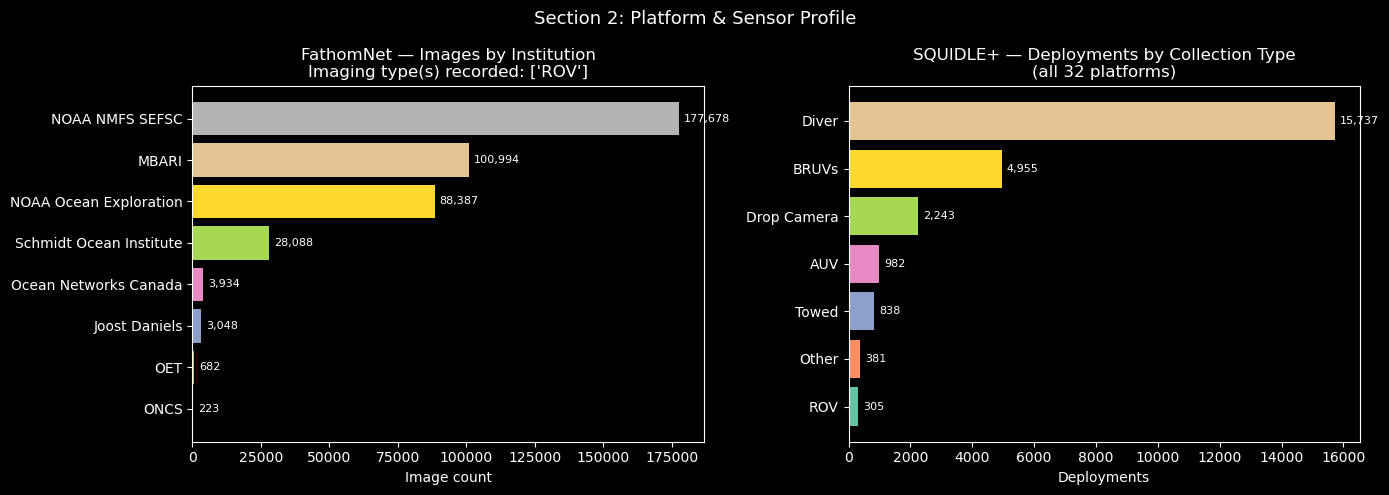


→ FINDING 2:
  FathomNet: 9 contributors; top 3 = 91% of images.
  Imaging type is recorded as ['ROV'] — not systematically tracked across all images.
  SQUIDLE+ collection types: Diver, BRUVs, Drop Camera, AUV, Towed, Other, ROV — explicit for every deployment.


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 2: Platform & Sensor Profile', fontsize=13)

# ── Left: FathomNet — institution breakdown + imaging type note ───────────
top_contrib = contrib_df.head(8)
bars_fn = axes[0].barh(top_contrib['institution'][::-1], top_contrib['images'][::-1],
                       color=plt.cm.Set2.colors[:len(top_contrib)], edgecolor='none')
for bar, val in zip(bars_fn, top_contrib['images'][::-1]):
    axes[0].text(val + top_contrib['images'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=8)
axes[0].set_title(f'FathomNet — Images by Institution\n'
                  f'Imaging type(s) recorded: {fn_imaging_types}')
axes[0].set_xlabel('Image count')

# ── Right: SQUIDLE+ — deployments by collection type ─────────────────────
ordered = sq_type_dep_df.sort_values('n_deployments', ascending=True)
bars_sq = axes[1].barh(ordered['type'], ordered['n_deployments'],
                       color=plt.cm.Set2.colors[:len(ordered)], edgecolor='none')
for bar, (_, row) in zip(bars_sq, ordered.iterrows()):
    axes[1].text(row['n_deployments'] + ordered['n_deployments'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"{row['n_deployments']:,}", va='center', fontsize=8)
axes[1].set_title('SQUIDLE+ — Deployments by Collection Type\n(all 32 platforms)')
axes[1].set_xlabel('Deployments')

plt.tight_layout()
plt.show()

top3_pct = contrib_df.head(3)['images'].sum() / contrib_df['images'].sum() * 100
active_sq_types = sq_type_dep_df[sq_type_dep_df['n_deployments'] > 0]['type'].tolist()
print(f'\n→ FINDING 2:')
print(f'  FathomNet: {len(fn_distinct_subs)} contributors; top 3 = {top3_pct:.0f}% of images.')
print(f'  Imaging type is recorded as {fn_imaging_types} — not systematically tracked across all images.')
print(f'  SQUIDLE+ collection types: {", ".join(active_sq_types)} — explicit for every deployment.')

---
## 3. Geographic, Depth, and Time Coverage
Where and when in the world and at what depths was this data collected?

In [47]:
# FathomNet image sample — 100 pages spread evenly across all 448K images.
# 'number' is the correct Pageable field (not 'page'); uses fn_total_images from s1-fn.
_page_size   = 200
_n_pages     = 200
_total_pages = fn_total_images // _page_size

fn_sample = []
for i in range(_n_pages):
    _num = int(i * _total_pages / _n_pages)
    fn_sample.extend(images.find_all_alt(Pageable(number=_num, size=_page_size)))
fn_sample = list({(img.uuid or id(img)): img for img in fn_sample}.values())

fn_df = pd.DataFrame([{
    'uuid':         i.uuid,
    'url':          i.url,
    'imaging_type': getattr(i, 'imagingType', None),
    'depth_m':      getattr(i, 'depthMeters', None),
    'latitude':     getattr(i, 'latitude', None),
    'longitude':    getattr(i, 'longitude', None),
    'timestamp':    getattr(i, 'createdTimestamp', None),
    'n_boxes':      len(i.boundingBoxes) if getattr(i, 'boundingBoxes', None) else 0,
} for i in fn_sample])
fn_df['timestamp'] = pd.to_datetime(fn_df['timestamp'], errors='coerce')
fn_df['year'] = fn_df['timestamp'].dt.year

fn_geo   = fn_df.dropna(subset=['latitude', 'longitude'])
fn_depth = fn_df['depth_m'].dropna()

print(f'FathomNet: {len(fn_df):,} images across {_n_pages} evenly-spaced pages '
      f'({len(fn_geo):,} geolocated, {len(fn_depth):,} with depth)')
if len(fn_depth):
    print(f'Depth:  {fn_depth.min():.0f}m – {fn_depth.max():.0f}m  |  median {fn_depth.median():.0f}m')
if len(fn_geo):
    print(f'Lat:    {fn_geo["latitude"].min():.1f}° – {fn_geo["latitude"].max():.1f}°')
    print(f'Lon:    {fn_geo["longitude"].min():.1f}° – {fn_geo["longitude"].max():.1f}°')
if fn_df['year'].notna().any():
    print(f'Years:  {int(fn_df["year"].min())} – {int(fn_df["year"].max())}')


FathomNet: 40,000 images across 200 evenly-spaced pages (19,231 geolocated, 10,622 with depth)
Depth:  3m – 5831m  |  median 866m
Lat:    -17.4° – 52.1°
Lon:    -178.4° – 171.2°
Years:  2021 – 2026


In [48]:
# SQUIDLE+ depth & temporal distribution — aggregate counts from all deployments.
# dep_max = maximum depth reached during a deployment (not per-image depth).
# Each bin = 1 API call returning num_results only; no records fetched.

# ── Depth distribution ────────────────────────────────────────────────────
_depth_bins = [
    (0,    30,   '0–30m'),
    (30,   100,  '30–100m'),
    (100,  300,  '100–300m'),
    (300,  1000, '300–1000m'),
    (1000, 3000, '1000–3000m'),
    (3000, None, '>3000m'),
]
sq_depth_rows = []
for lo, hi, label in _depth_bins:
    filters = [{'name': 'dep_max', 'op': '>=', 'val': lo}]
    if hi:
        filters.append({'name': 'dep_max', 'op': '<', 'val': hi})
    n = sq_get('/api/deployment', {'q': {'filters': filters}, 'results_per_page': 1}).get('num_results', 0)
    sq_depth_rows.append({'bin': label, 'n_deployments': n})
sq_depth_df = pd.DataFrame(sq_depth_rows)

# ── Year distribution ─────────────────────────────────────────────────────
sq_year_rows = []
for yr in range(2007, 2026):
    q = {'filters': [{'name': 'timestamp_start', 'op': '>=', 'val': f'{yr}-01-01'},
                     {'name': 'timestamp_start', 'op': '<',  'val': f'{yr+1}-01-01'}]}
    n = sq_get('/api/deployment', {'q': q, 'results_per_page': 1}).get('num_results', 0)
    if n:
        sq_year_rows.append({'year': yr, 'n_deployments': n})
sq_year_df = pd.DataFrame(sq_year_rows)

print(f'  sq_depth_df: {len(sq_depth_df)} depth bins — total deployments = {sq_depth_df["n_deployments"].sum():,}')
print(f'  sq_year_df:  {len(sq_year_df)} years ({sq_year_df["year"].min()}–{sq_year_df["year"].max()})')


  sq_depth_df: 6 depth bins — total deployments = 25,124
  sq_year_df:  19 years (2007–2025)


In [49]:
# ── Section 3 geo data: coastlines + SQUIDLE+ 72-cell geographic grid ─────
# Run once. Re-run s3-viz freely to adjust the plot without re-fetching.

try:
    _coast_url = ('https://raw.githubusercontent.com/nvkelso/natural-earth-vector'
                  '/master/geojson/ne_110m_coastline.geojson')
    _coast_data = requests.get(_coast_url, timeout=20).json()
    _coast_segs = []
    for _feat in _coast_data['features']:
        _geom = _feat['geometry']
        if _geom['type'] == 'LineString':
            _coast_segs.append(_geom['coordinates'])
        elif _geom['type'] == 'MultiLineString':
            _coast_segs.extend(_geom['coordinates'])
    print(f'Loaded {len(_coast_segs)} coastline segments')
except Exception as _ce:
    _coast_segs = []
    print(f'Coastlines unavailable ({_ce})')

def _draw_coast(ax, color='#777777', lw=0.45, zorder=2):
    for seg in _coast_segs:
        ax.plot([c[0] for c in seg], [c[1] for c in seg],
                color=color, lw=lw, zorder=zorder)

# 72-cell 30°×30° grid — counts only, no records fetched
print('Querying SQUIDLE+ geographic grid (72 cells × 1 API call each)...')
_grid_rows, _total = [], 0
for _lat in range(-90, 90, 30):
    for _lon in range(-180, 180, 30):
        _q = {'filters': [{'name': 'lat', 'op': '>=', 'val': _lat},
                           {'name': 'lat', 'op': '<',  'val': _lat + 30},
                           {'name': 'lon', 'op': '>=', 'val': _lon},
                           {'name': 'lon', 'op': '<',  'val': _lon + 30}]}
        _n = sq_get('/api/pose', {'q': _q, 'results_per_page': 1}).get('num_results', 0)
        _grid_rows.append({'lat_s': _lat, 'lon_s': _lon,
                           'lat_c': _lat + 15, 'lon_c': _lon + 15, 'count': _n})
        _total += _n
        time.sleep(0.05)
grid_df = pd.DataFrame(_grid_rows).sort_values('count', ascending=False)
nonzero  = grid_df[grid_df['count'] > 0]
print(f'Done — {len(nonzero)}/72 cells have data, {_total:,} geolocated poses')

Loaded 134 coastline segments
Querying SQUIDLE+ geographic grid (72 cells × 1 API call each)...
Done — 43/72 cells have data, 10,484,239 geolocated poses


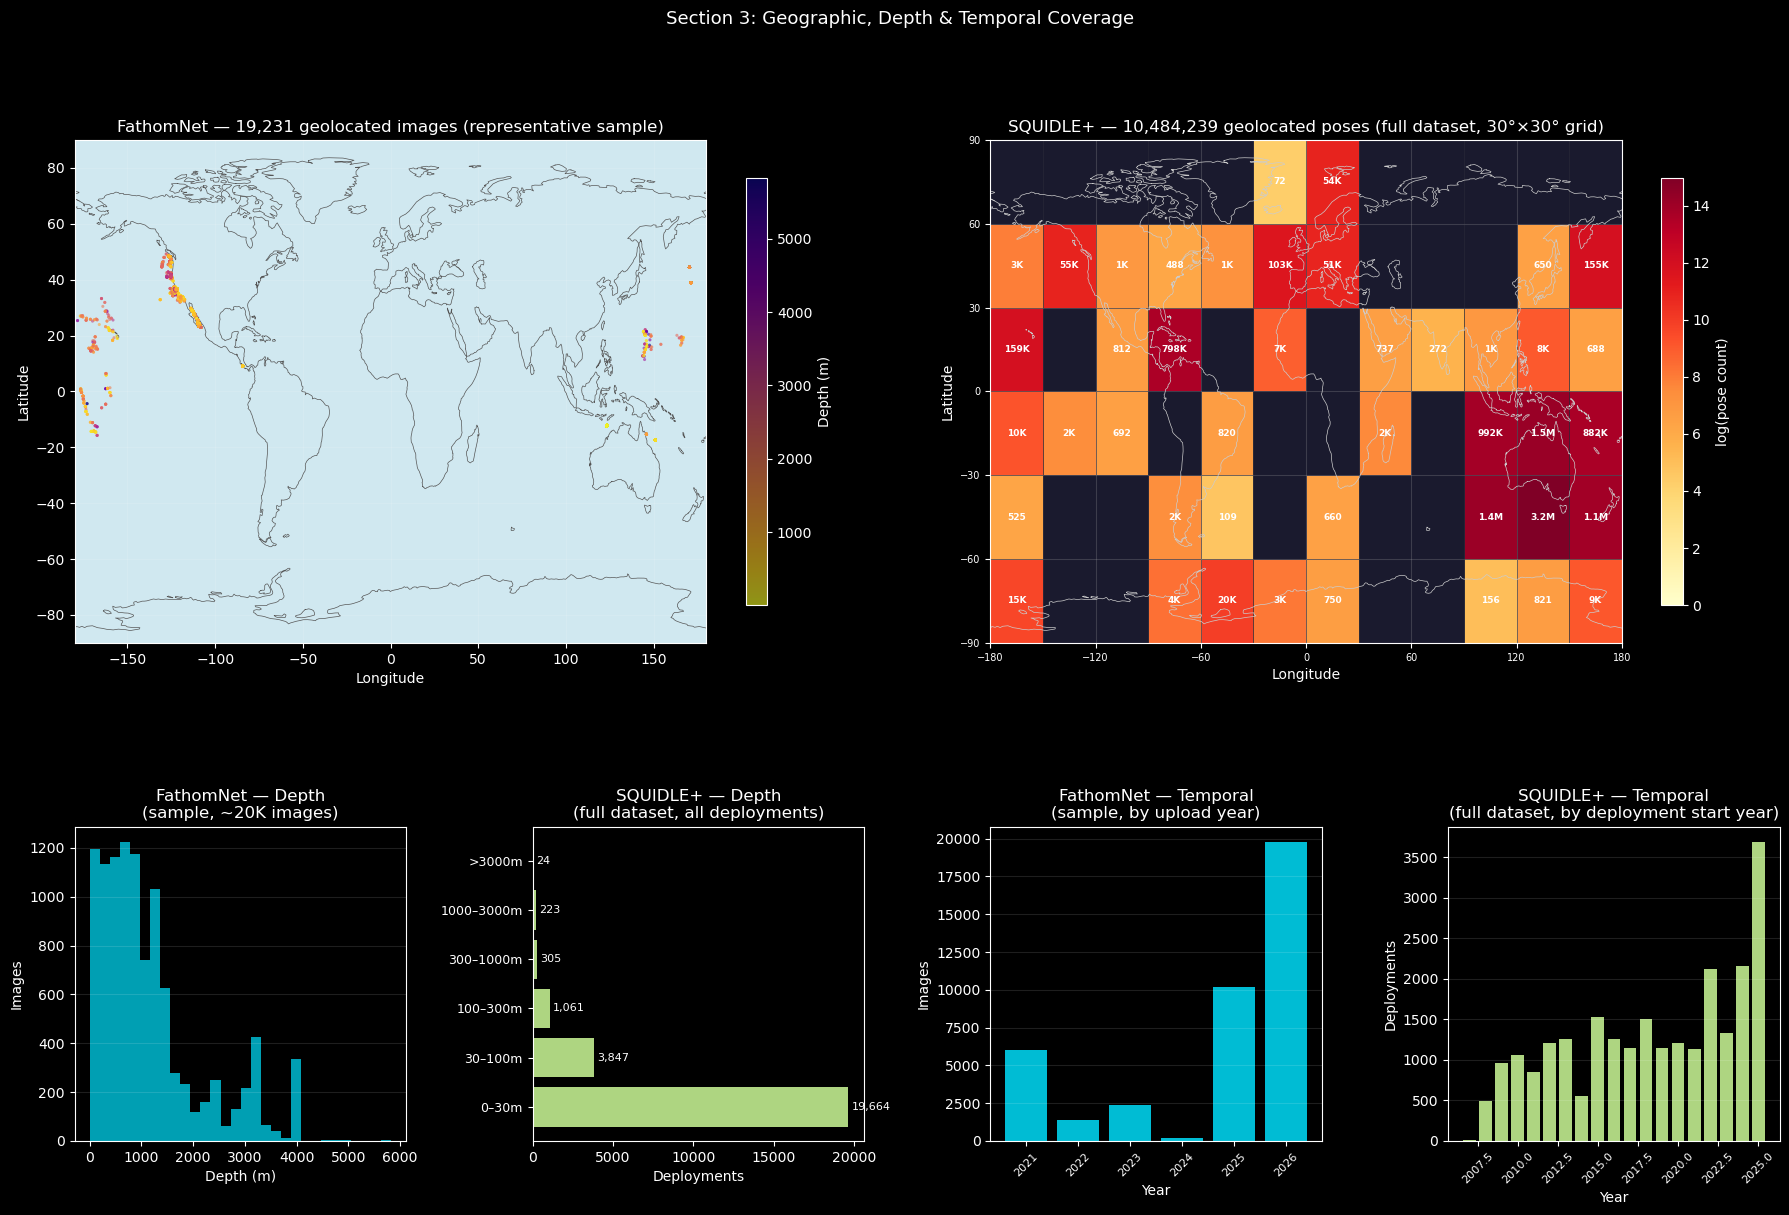


→ FINDING 3:
  FathomNet: 5% shallow (<100m), median 866m (sample-based)
  SQUIDLE+:  94% of deployments shallow (<100m) — full dataset
  SQUIDLE+:  43/72 global cells covered; top 3 cells = 58% of poses
  SQUIDLE+:  active 2007–2025, peak year 2025


In [50]:
# ── Figure: 2×4 grid ──────────────────────────────────────────────────────
# Row 0: FathomNet map (cols 0-1) | SQUIDLE+ map (cols 2-3)
# Row 1: FN depth | SQ depth | FN year | SQ year
# Data comes from: 48ff65d7 (fn_*), s3-sq (sq_depth_df, sq_year_df), s28rterjdc (grid_df, _coast_segs)
fig = plt.figure(figsize=(22, 13))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38,
                        height_ratios=[1.6, 1])
fig.suptitle('Section 3: Geographic, Depth & Temporal Coverage', fontsize=13)

# ── Top-left: FathomNet scatter on world map ───────────────────────────────
ax_fn = fig.add_subplot(gs[0, 0:2])
ax_fn.set_facecolor('#d0e8f0')
_draw_coast(ax_fn, color='#555555', lw=0.5)
sc = ax_fn.scatter(fn_geo['longitude'], fn_geo['latitude'],
                   c=fn_geo['depth_m'], cmap='plasma_r', s=5, alpha=0.6,
                   edgecolors='none', zorder=3)
plt.colorbar(sc, ax=ax_fn, label='Depth (m)', shrink=0.85)
ax_fn.set_xlim(-180, 180); ax_fn.set_ylim(-90, 90)
ax_fn.set_title(f'FathomNet — {len(fn_geo):,} geolocated images (representative sample)')
ax_fn.set_xlabel('Longitude'); ax_fn.set_ylabel('Latitude')
ax_fn.grid(True, alpha=0.12, zorder=0)

# ── Top-right: SQUIDLE+ grid heatmap on world map ─────────────────────────
ax_sq = fig.add_subplot(gs[0, 2:4])
ax_sq.set_xlim(-180, 180); ax_sq.set_ylim(-90, 90)
ax_sq.set_facecolor('#0d0d1a')
_max = grid_df['count'].max()
_cmap = plt.cm.YlOrRd
_norm = plt.Normalize(0, np.log1p(_max))
for _, row in grid_df.iterrows():
    color = '#1a1a2e' if row['count'] == 0 else _cmap(_norm(np.log1p(row['count'])))
    ax_sq.add_patch(mpatches.Rectangle(
        (row['lon_s'], row['lat_s']), 30, 30,
        linewidth=0.4, edgecolor='#2a2a3a', facecolor=color, zorder=1))
    if row['count'] > 0:
        lbl = (f"{row['count']/1e6:.1f}M" if row['count'] >= 1e6 else
               f"{row['count']/1e3:.0f}K"  if row['count'] >= 1000 else str(int(row['count'])))
        ax_sq.text(row['lon_c'], row['lat_c'], lbl,
                   ha='center', va='center', fontsize=6.5, color='white',
                   fontweight='bold', zorder=4)
_draw_coast(ax_sq, color='#cccccc', lw=0.5)
sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
sm.set_array([])
plt.colorbar(sm, ax=ax_sq, label='log(pose count)', shrink=0.85)
ax_sq.set_title(f'SQUIDLE+ — {_total:,} geolocated poses (full dataset, 30°×30° grid)')
ax_sq.set_xlabel('Longitude'); ax_sq.set_ylabel('Latitude')
ax_sq.set_xticks(range(-180, 181, 60)); ax_sq.set_yticks(range(-90, 91, 30))
ax_sq.tick_params(labelsize=7); ax_sq.grid(True, alpha=0.12, zorder=0)

# ── Bottom-left: FathomNet depth histogram (sample) ────────────────────────
ax_fn_dep = fig.add_subplot(gs[1, 0])
ax_fn_dep.hist(fn_depth, bins=30, color='#00bcd4', edgecolor='none', alpha=0.85)
ax_fn_dep.set_title('FathomNet — Depth\n(sample, ~20K images)')
ax_fn_dep.set_xlabel('Depth (m)'); ax_fn_dep.set_ylabel('Images')
ax_fn_dep.grid(True, alpha=0.12, axis='y')

# ── Bottom second: SQUIDLE+ depth bar chart (full dataset) ────────────────
ax_sq_dep = fig.add_subplot(gs[1, 1])
ax_sq_dep.barh(sq_depth_df['bin'], sq_depth_df['n_deployments'],
               color='#aed581', edgecolor='none')
ax_sq_dep.set_title('SQUIDLE+ — Depth\n(full dataset, all deployments)')
ax_sq_dep.set_xlabel('Deployments')
ax_sq_dep.tick_params(axis='y', labelsize=9)
for i, val in enumerate(sq_depth_df['n_deployments']):
    ax_sq_dep.text(val + sq_depth_df['n_deployments'].max() * 0.01, i,
                   f'{val:,}', va='center', fontsize=8)

# ── Bottom third: FathomNet year bar chart (sample) ───────────────────────
ax_fn_yr = fig.add_subplot(gs[1, 2])
fn_yr_counts = fn_df['year'].dropna().astype(int).value_counts().sort_index()
ax_fn_yr.bar(fn_yr_counts.index, fn_yr_counts.values,
             color='#00bcd4', edgecolor='none', width=0.8)
ax_fn_yr.set_title('FathomNet — Temporal\n(sample, by upload year)')
ax_fn_yr.set_xlabel('Year'); ax_fn_yr.set_ylabel('Images')
ax_fn_yr.tick_params(axis='x', rotation=45, labelsize=8)
ax_fn_yr.grid(True, alpha=0.12, axis='y')

# ── Bottom-right: SQUIDLE+ year bar chart (full dataset) ──────────────────
ax_sq_yr = fig.add_subplot(gs[1, 3])
ax_sq_yr.bar(sq_year_df['year'], sq_year_df['n_deployments'],
             color='#aed581', edgecolor='none', width=0.8)
ax_sq_yr.set_title('SQUIDLE+ — Temporal\n(full dataset, by deployment start year)')
ax_sq_yr.set_xlabel('Year'); ax_sq_yr.set_ylabel('Deployments')
ax_sq_yr.tick_params(axis='x', rotation=45, labelsize=8)
ax_sq_yr.grid(True, alpha=0.12, axis='y')

plt.show()

fn_shallow   = (fn_depth < 100).sum() / len(fn_depth) * 100 if len(fn_depth) else 0
sq_shallow_n = sq_depth_df[sq_depth_df['bin'].isin(['0–30m', '30–100m'])]['n_deployments'].sum()
sq_total_dep = sq_depth_df['n_deployments'].sum()
sq_shallow   = sq_shallow_n / sq_total_dep * 100 if sq_total_dep else 0
top3_pct     = grid_df.head(3)['count'].sum() / max(_total, 1) * 100

print(f'\n→ FINDING 3:')
print(f'  FathomNet: {fn_shallow:.0f}% shallow (<100m), median {fn_depth.median():.0f}m (sample-based)')
print(f'  SQUIDLE+:  {sq_shallow:.0f}% of deployments shallow (<100m) — full dataset')
print(f'  SQUIDLE+:  {len(nonzero)}/72 global cells covered; top 3 cells = {top3_pct:.0f}% of poses')
print(f'  SQUIDLE+:  active {sq_year_df["year"].min()}–{sq_year_df["year"].max()}, '
      f'peak year {sq_year_df.loc[sq_year_df["n_deployments"].idxmax(), "year"]}')

---
## 4. Annotation Landscape
What is actually labeled in each database, and how?
This determines which habitat classes you can train on and whether annotations
are compatible with your model architecture.

In [51]:
# FathomNet concept distribution — comprehensive from boundingboxes.count_total_by_concept().
# sorted_dict = {concept: total_count} for all unique concepts across all 448K images.
# No sampling — this is the complete ground truth.
concept_dict = {item.concept: item.count for item in boundingboxes.count_total_by_concept()}
sorted_dict = dict(sorted(concept_dict.items(), key=lambda item: item[1], reverse=True))

fn_concept_df = (pd.DataFrame(sorted_dict.items(), columns=['concept', 'n_boxes'])
                   .sort_values('n_boxes', ascending=False)
                   .reset_index(drop=True))

n_total = fn_concept_df['n_boxes'].sum()
print(f'{n_total:,} total bounding boxes | {len(fn_concept_df):,} unique concepts (full taxonomy)')
print()

q = fn_concept_df['n_boxes']
print('Box count per concept — descriptive stats:')
print(q.describe(percentiles=[.25, .5, .75, .99]).to_string())
print()

for n in [1, 5, 20]:
    pct = fn_concept_df.head(n)['n_boxes'].sum() / n_total * 100
    print(f'  Top {n:>2} concepts: {pct:.0f}% of all boxes')
n_for_80 = int((q.cumsum() / n_total < 0.8).sum()) + 1
print(f'  {n_for_80} concepts account for 80% of all boxes')
print()

print()
print('Top 20 concepts:')
print(fn_concept_df.head(20).to_string(index=False))


1,082,105 total bounding boxes | 2,870 unique concepts (full taxonomy)

Box count per concept — descriptive stats:
count      2870.000000
mean        377.040070
std        3372.669771
min           1.000000
25%           2.000000
50%           7.000000
75%          49.000000
99%        7007.000000
max      151292.000000

  Top  1 concepts: 14% of all boxes
  Top  5 concepts: 26% of all boxes
  Top 20 concepts: 47% of all boxes
  117 concepts account for 80% of all boxes


Top 20 concepts:
                     concept  n_boxes
        Lutjanus campechanus   151292
                     sea fan    51480
         Stenotomus caprinus    26775
     Rhomboplites aurorubens    25825
             marine organism    23173
 Strongylocentrotus fragilis    23061
                   bony fish    21664
                Ptereleotris    21131
                      sponge    21107
               Pagrus pagrus    17028
                     Chromis    15769
         Mycteroperca phenax    15347
           E

In [52]:
# Bounding box density: how many boxes per image?
fn_box_density = fn_df[fn_df['n_boxes'] > 0]['n_boxes']

print('FathomNet bounding box statistics (annotated images only):')
print(f'  Images with ≥1 box:  {len(fn_box_density):,} ({len(fn_box_density)/len(fn_df)*100:.0f}%)')
print(f'  Median boxes/image:  {fn_box_density.median():.1f}')
print(f'  Max boxes/image:     {fn_box_density.max()}')
print(f'  >5 boxes:            {(fn_box_density>5).sum():,} images ({(fn_box_density>5).mean()*100:.0f}%)')
print()
_med = fn_box_density.median()
_pct_over = (fn_box_density > _med).mean() * 100
print(f'  NOTE: median {_med:.0f} boxes/image; {_pct_over:.0f}% exceed the median — right-skewed')
print(f'  distribution (max {fn_box_density.max()}). Crowded images contribute disproportionately')
print(f'  to training loss — consider capping boxes per image or applying image-level weighting.')

FathomNet bounding box statistics (annotated images only):
  Images with ≥1 box:  35,890 (90%)
  Median boxes/image:  1.0
  Max boxes/image:     163
  >5 boxes:            3,967 images (11%)

  NOTE: median 1 boxes/image; 46% exceed the median — right-skewed
  distribution (max 163). Crowded images contribute disproportionately
  to training loss — consider capping boxes per image or applying image-level weighting.


In [53]:
# ── Step 1: Full label catalogue ──────────────────────────────────────────
if 'sq_label_df' not in dir() or len(sq_label_df) == 0:
    print('Fetching SQUIDLE+ label catalogue...')
    sq_label_catalogue = []
    page = 1
    while True:
        batch = sq_get('/api/label', {'results_per_page': 1000, 'page': page})
        objects = batch.get('objects', [])
        if not objects: break
        sq_label_catalogue.extend(objects)
        if page >= batch.get('total_pages', 1): break
        page += 1
        time.sleep(0.02)
    sq_label_df = pd.DataFrame(sq_label_catalogue)
print(f'Label catalogue: {len(sq_label_df):,} labels')

# Check whether annotation_count came back in the bulk list response.
# API docs list it as an included field on /api/label/<id>; availability in
# list responses depends on server configuration.
_has_ann_count = (
    'annotation_count' in sq_label_df.columns
    and sq_label_df['annotation_count'].notna().any()
)
print(f'annotation_count in catalogue: {_has_ann_count}')

# ── Step 2: Parse lineage list → ancestor names at every depth ─────────────
def ancestors_from_lineage(val):
    if isinstance(val, (list, np.ndarray)):
        out = []
        for item in val:
            out.append(str(item.get('name', '')).strip() if isinstance(item, dict) else str(item).strip())
        return out
    if isinstance(val, dict):
        return [str(val.get('name', '')).strip()]
    try:
        if pd.isna(val): return []
    except (TypeError, ValueError):
        pass
    s = str(val).strip()
    return [p.strip() for p in s.split(' > ')] if ' > ' in s else ([s] if s else [])

sq_label_df['ancestors'] = sq_label_df['lineage'].apply(ancestors_from_lineage)
sq_label_df['top_level'] = sq_label_df['ancestors'].apply(lambda a: a[0] if a else 'Unknown')

# ── Step 3: Label counts per lineage depth (for reference only) ────────────
max_depth = sq_label_df['ancestors'].apply(len).max()
level_summaries = {}
for depth in range(max_depth):
    vals = sq_label_df['ancestors'].apply(lambda a: a[depth] if len(a) > depth else None)
    level_summaries[depth] = vals.dropna().value_counts()

# ── Step 4: Annotation counts ─────────────────────────────────────────────
# Fast path: annotation_count is a field on each label object — pure pandas,
#            zero extra API calls. Sum per-label counts up to any ancestor depth.
#
# Fallback:  annotation_count not in bulk response — query /api/annotation
#            with label_id in [...] filters, parallelised across categories,
#            chunk_size=150 to stay within server URI length limits.

if _has_ann_count:
    print('\nUsing annotation_count field — no extra API calls needed.')

    def query_level_annotations(depth, top_n=12):
        df = (sq_label_df[sq_label_df['ancestors'].apply(len) > depth]
              .assign(category=lambda d: d['ancestors'].apply(lambda a: a[depth]))
              .groupby('category', as_index=False)
              .agg(n_labels=('id', 'count'), n_annotations=('annotation_count', 'sum'))
              .sort_values('n_annotations', ascending=False)
              .reset_index(drop=True))
        print(f'  Depth {depth}: {len(df)} categories')
        print(df.head(top_n)[['category', 'n_labels', 'n_annotations']].to_string(index=False))
        return df

else:
    print('\nAnnotation count not in catalogue — using parallelised API queries.')
    from concurrent.futures import ThreadPoolExecutor, as_completed

    def count_annotations_for_ids(label_ids, chunk_size=150):
        """Sum annotation num_results across chunked label_id in-filters."""
        ids = [int(x) for x in label_ids]
        total = 0
        for i in range(0, len(ids), chunk_size):
            chunk = ids[i:i + chunk_size]
            q = {'filters': [{'name': 'label_id', 'op': 'in', 'val': chunk}]}
            try:
                total += sq_get('/api/annotation', {'q': q, 'results_per_page': 1}).get('num_results', 0)
            except Exception as e:
                print(f'    chunk error: {e}')
        return total

    def query_level_annotations(depth, top_n=12, max_workers=8):
        """Query annotation counts for all categories at a given lineage depth,
        parallelised across categories with ThreadPoolExecutor."""
        cat_to_ids = {}
        for _, row in sq_label_df.iterrows():
            a = row['ancestors']
            if len(a) > depth:
                cat_to_ids.setdefault(a[depth], []).append(int(row['id']))

        n_cats = len(cat_to_ids)
        n_calls = sum(max(1, (len(ids) + 149) // 150) for ids in cat_to_ids.values())
        print(f'  Depth {depth}: {n_cats} categories, ~{n_calls} API calls ({max_workers} workers)')

        rows = []
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = {ex.submit(count_annotations_for_ids, ids): (cat, len(ids))
                       for cat, ids in cat_to_ids.items()}
            for i, fut in enumerate(as_completed(futures)):
                cat, n_labels = futures[fut]
                rows.append({'category': cat, 'n_labels': n_labels, 'n_annotations': fut.result()})
                if (i + 1) % 20 == 0:
                    print(f'    {i+1}/{n_cats} done...')

        df = (pd.DataFrame(rows)
                .sort_values('n_annotations', ascending=False)
                .reset_index(drop=True))
        print(df.head(top_n)[['category', 'n_labels', 'n_annotations']].to_string(index=False))
        return df

# ── Step 4a–c: Query levels 0, 1, 2 ──────────────────────────────────────
print('\n── Level 0 annotation counts ──')
sq_cat_df = query_level_annotations(depth=0)
print('\n── Level 1 annotation counts ──')
sq_cat_df_l1 = query_level_annotations(depth=1)
print('\n── Level 2 annotation counts ──')
sq_cat_df_l2 = query_level_annotations(depth=2)

# ── Step 5: Small annotation sample for s4-viz density + s5 gallery ────────
print('\nFetching annotation sample...')
sq_ann_sample, sq_ann_total = sq_pages(
    '/api/annotation',
    params={'include_columns': ['id', 'label', 'point']},
    max_records=2000
)
print(f'Sample: {len(sq_ann_sample):,} of {sq_ann_total:,}')

Label catalogue: 27,942 labels
annotation_count in catalogue: False

Annotation count not in catalogue — using parallelised API queries.

── Level 0 annotation counts ──
  Depth 0: 140 categories, ~319 API calls (8 workers)
    20/140 done...
    40/140 done...
    60/140 done...
    80/140 done...
    100/140 done...
    120/140 done...
    140/140 done...
       category  n_labels  n_annotations
     2 Physical        54        1233957
      1.1 Biota      1964        1012972
          Biota      2833         275367
  Morphospecies     12615          98378
     Unscorable        14          93738
       Physical        27          45682
3 Field of View        10          18097
       Category      4087          13403
           Kelp         2           8267
           Turf         1           7450
       Sand-Mud         1           7121
     Substratum       264           6847

── Level 1 annotation counts ──
  Depth 1: 166 categories, ~321 API calls (8 workers)
    20/166 done...
 

In [ ]:
#sample of label hierarchy
sq_label_df[sq_label_df['name_path'].str.contains('Coral')].groupby('name_path').size().sort_values(ascending=False).head(20)

name_path
1.1 Biota > Cnidaria > Corals > Stony corals > Branching > Pocillopora damicornis    3
Substratum > Soft > Unconsolidated > Coarse > Coral > Coral rubble                   2
Category > Ecological status > Habitat > Coral habitat > Rubbish present             2
Category > Geoform > Element > Coral > Front reef groove                             2
Category > Geoform > Element > Coral > Crest channel                                 2
Category > Geoform > Element > Coral > Coralgal rim                                  2
Category > Geoform > Element > Coral > Coralgal ridge                                2
Category > Geoform > Element > Coral > Buttress spur                                 2
Category > Geoform > Element > Coral > Buttress front wall                           2
Category > Geoform > Element > Coral > Buttress crownhead                            2
Category > Geoform > Element > Coral                                                 2
Category > Ecological status > Ha

#### A note on SQUIDLE+ label taxonomy: parallel axes within CATAMI and real-world messiness

The 27,942-label catalogue is built on the **CATAMI classification scheme**, but CATAMI is not a single hierarchy — it defines multiple parallel classification axes for the same scene. A single real-world object like "Coral" appears simultaneously under at least four different CATAMI axes depending on what the annotator was recording:

| Lineage path (excerpt) | CATAMI axis |
|---|---|
| `1.1 Biota > Cnidaria > Corals > Stony corals > ...` | What organism is present (biota identity) |
| `Substratum > Soft > Unconsolidated > Coarse > Coral rubble` | What the seafloor substrate is (physical substrate) |
| `Category > Geoform > Element > Coral > Front reef groove` | The geomorphological context of the feature |
| `Category > Ecological status > Habitat > Coral habitat > Coral bleaching` | The ecological condition of the habitat |

This has direct consequences for training:
- **Filtering on a keyword alone is unreliable** — `"Coral"` matches biota, substrate, geoform, and health labels simultaneously across different CATAMI axes.
- **Annotation counts across axes are not comparable** — a campaign focused on substrate will inflate `Substratum > Coral rubble` counts with no corresponding `Biota > Corals` labels.
- **Axis selection is a prerequisite** — before building a training set, decide which CATAMI axis you need (e.g. substrate only) and discard labels from other axes rather than pooling them.
- **Label sparsity at fine grain is real** — many specific labels in the catalogue have only 2–3 annotations globally, making them unusable as standalone training classes without aggregation to a coarser level.

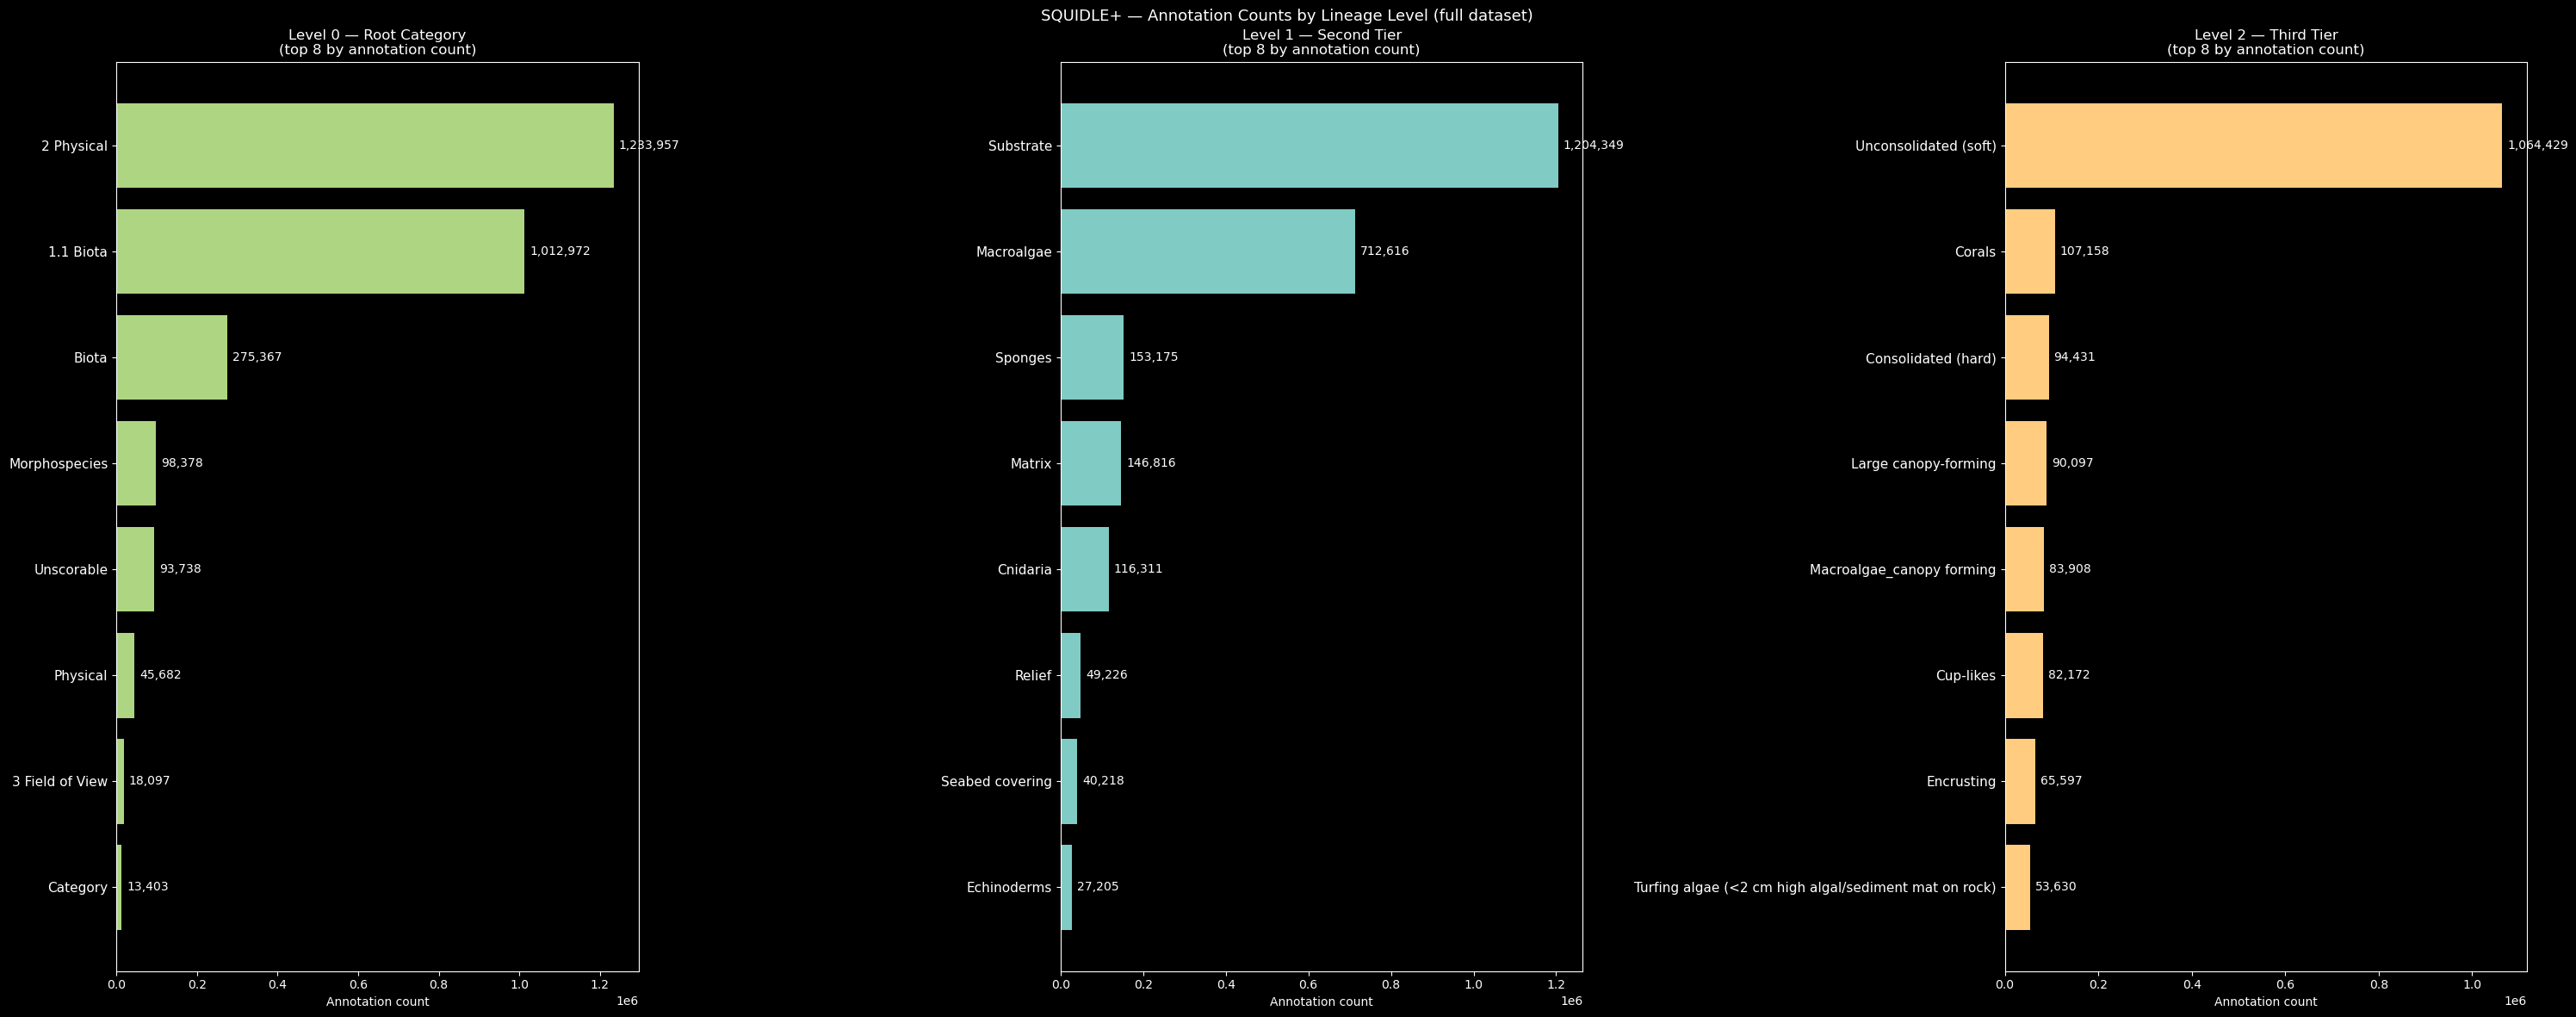


→ FINDING 4 (SQUIDLE+):
  Level 0: 140 root categories, 2,859,468 total annotations
  Level 1: most annotated — "Substrate" (1,204,349 annotations)
  Level 2: most annotated — "Unconsolidated (soft)" (1,064,429 annotations)
  Dominant root: "2 Physical" — 1,233,957 annotations


In [56]:
# ── SQUIDLE+ label taxonomy — annotation counts at levels 0, 1, 2 ─────────
level_ann_dfs   = [sq_cat_df.iloc[:8], sq_cat_df_l1.iloc[:8], sq_cat_df_l2.iloc[:8]]
level_ann_titles = [
    'Level 0 — Root Category\n(top 8 by annotation count)',
    'Level 1 — Second Tier\n(top 8 by annotation count)',
    'Level 2 — Third Tier\n(top 8 by annotation count)',
]
level_colors = ['#aed581', '#80cbc4', '#ffcc80']

fig, axes = plt.subplots(1, 3, figsize=(30, 12))
fig.suptitle('SQUIDLE+ — Annotation Counts by Lineage Level (full dataset)', fontsize=13)

for ax, df, title, color in zip(axes, level_ann_dfs, level_ann_titles, level_colors):
    if df.empty:
        ax.text(1, 1, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue
    plot_df = df.sort_values('n_annotations')
    ax.barh(plot_df['category'], plot_df['n_annotations'], color=color, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel('Annotation count')
    ax.tick_params(axis='y', labelsize=11)
    _max = plot_df['n_annotations'].max()
    for _, row in plot_df.iterrows():
        ax.text(row['n_annotations'] + _max * 0.01,
                plot_df.index.get_loc(row.name),
                f"{row['n_annotations']:,}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

total_ann = sq_cat_df['n_annotations'].sum()
top_cat   = sq_cat_df.iloc[0]
print(f'\n→ FINDING 4 (SQUIDLE+):')
print(f'  Level 0: {len(sq_cat_df)} root categories, {total_ann:,} total annotations')
if not sq_cat_df_l1.empty:
    top_l1 = sq_cat_df_l1.iloc[0]
    print(f'  Level 1: most annotated — "{top_l1["category"]}" ({top_l1["n_annotations"]:,} annotations)')
if not sq_cat_df_l2.empty:
    top_l2 = sq_cat_df_l2.iloc[0]
    print(f'  Level 2: most annotated — "{top_l2["category"]}" ({top_l2["n_annotations"]:,} annotations)')
print(f'  Dominant root: "{top_cat["category"]}" — {top_cat["n_annotations"]:,} annotations')


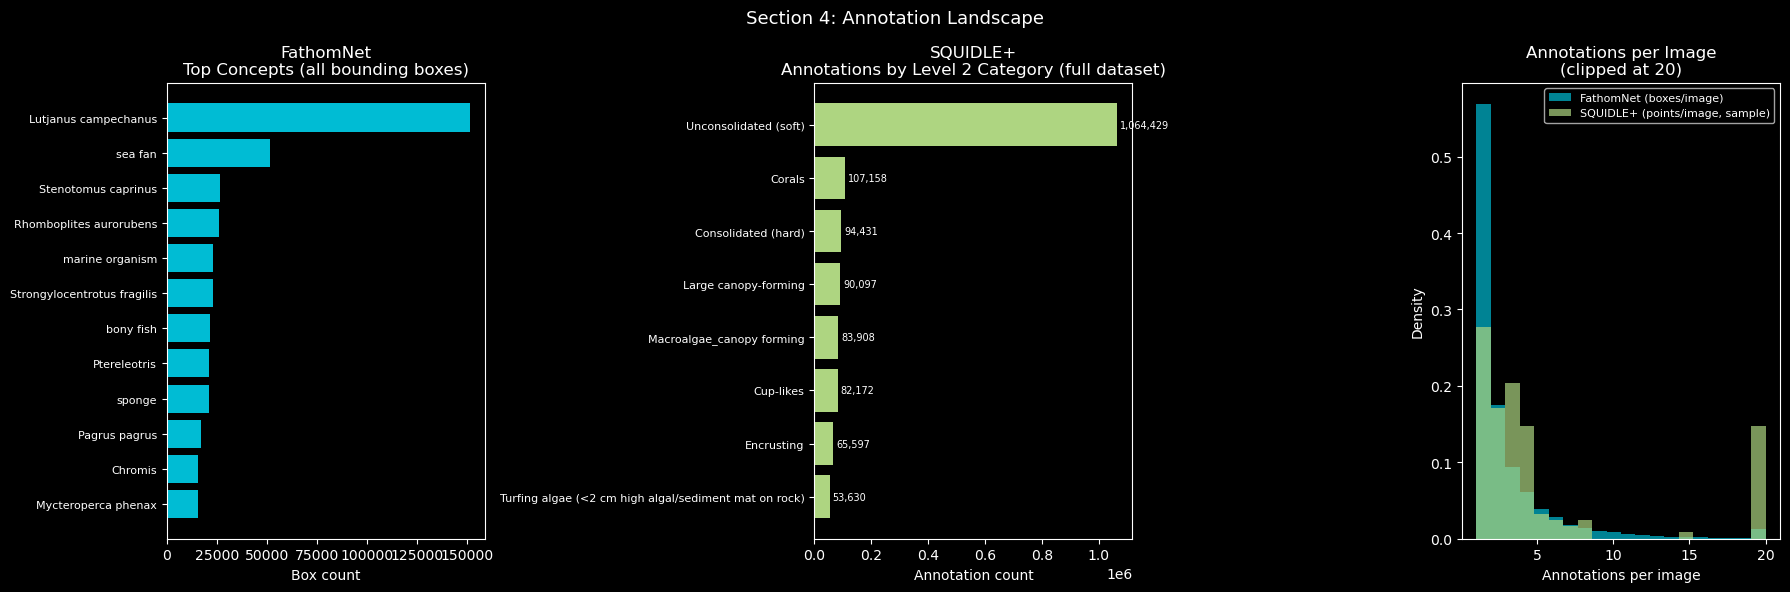


→ FINDING 4:
  FathomNet: organism/species bounding boxes — YOLO-ready format.
  SQUIDLE+:  habitat/substrate point labels (CATAMI) — needs conversion for detection.


In [57]:
# Per-image annotation density for SQUIDLE+ (from small sample)
sq_pts_per_img = Counter(
    a['point']['media_id'] for a in sq_ann_sample
    if a.get('point') and isinstance(a['point'], dict) and a['point'].get('media_id')
)
pts_series = pd.Series(list(sq_pts_per_img.values()))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Section 4: Annotation Landscape', fontsize=13)

# FathomNet: top concepts by total box count (comprehensive)
top_fn = fn_concept_df.head(12)
axes[0].barh(top_fn['concept'][::-1], top_fn['n_boxes'][::-1],
             color='#00bcd4', edgecolor='none')
axes[0].set_title('FathomNet\nTop Concepts (all bounding boxes)')
axes[0].set_xlabel('Box count'); axes[0].tick_params(axis='y', labelsize=8)

# SQUIDLE+: annotation count by Level 2 lineage category (full dataset)
sq_plot = sq_cat_df_l2.iloc[:8].dropna(subset=['n_annotations']).sort_values('n_annotations')
axes[1].barh(sq_plot['category'], sq_plot['n_annotations'],
             color='#aed581', edgecolor='none')
axes[1].set_title('SQUIDLE+\nAnnotations by Level 2 Category (full dataset)')
axes[1].set_xlabel('Annotation count'); axes[1].tick_params(axis='y', labelsize=8)
for i, (_, row) in enumerate(sq_plot.iterrows()):
    axes[1].text(row['n_annotations'] + sq_plot['n_annotations'].max() * 0.01, i,
                 f"{row['n_annotations']:,}", va='center', fontsize=7)

# Annotation density per image
axes[2].hist(fn_box_density.clip(upper=20), bins=20,
             color='#00bcd4', alpha=0.7, density=True, label='FathomNet (boxes/image)')
if len(pts_series):
    axes[2].hist(pts_series.clip(upper=20), bins=20,
                 color='#aed581', alpha=0.7, density=True, label='SQUIDLE+ (points/image, sample)')
axes[2].set_title('Annotations per Image\n(clipped at 20)')
axes[2].set_xlabel('Annotations per image'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\n→ FINDING 4:')
print('  FathomNet: organism/species bounding boxes — YOLO-ready format.')
print('  SQUIDLE+:  habitat/substrate point labels (CATAMI) — needs conversion for detection.')


---
## 5. Image Characteristics
Visual samples of annotated imagery from each database — bounding boxes (FathomNet) vs point labels (SQUIDLE+).
This illustrates annotation format, label density, and the visual character of each collection in practice.

FathomNet images with ≥1 box in sample: 35,890 of 40,000 (90%)


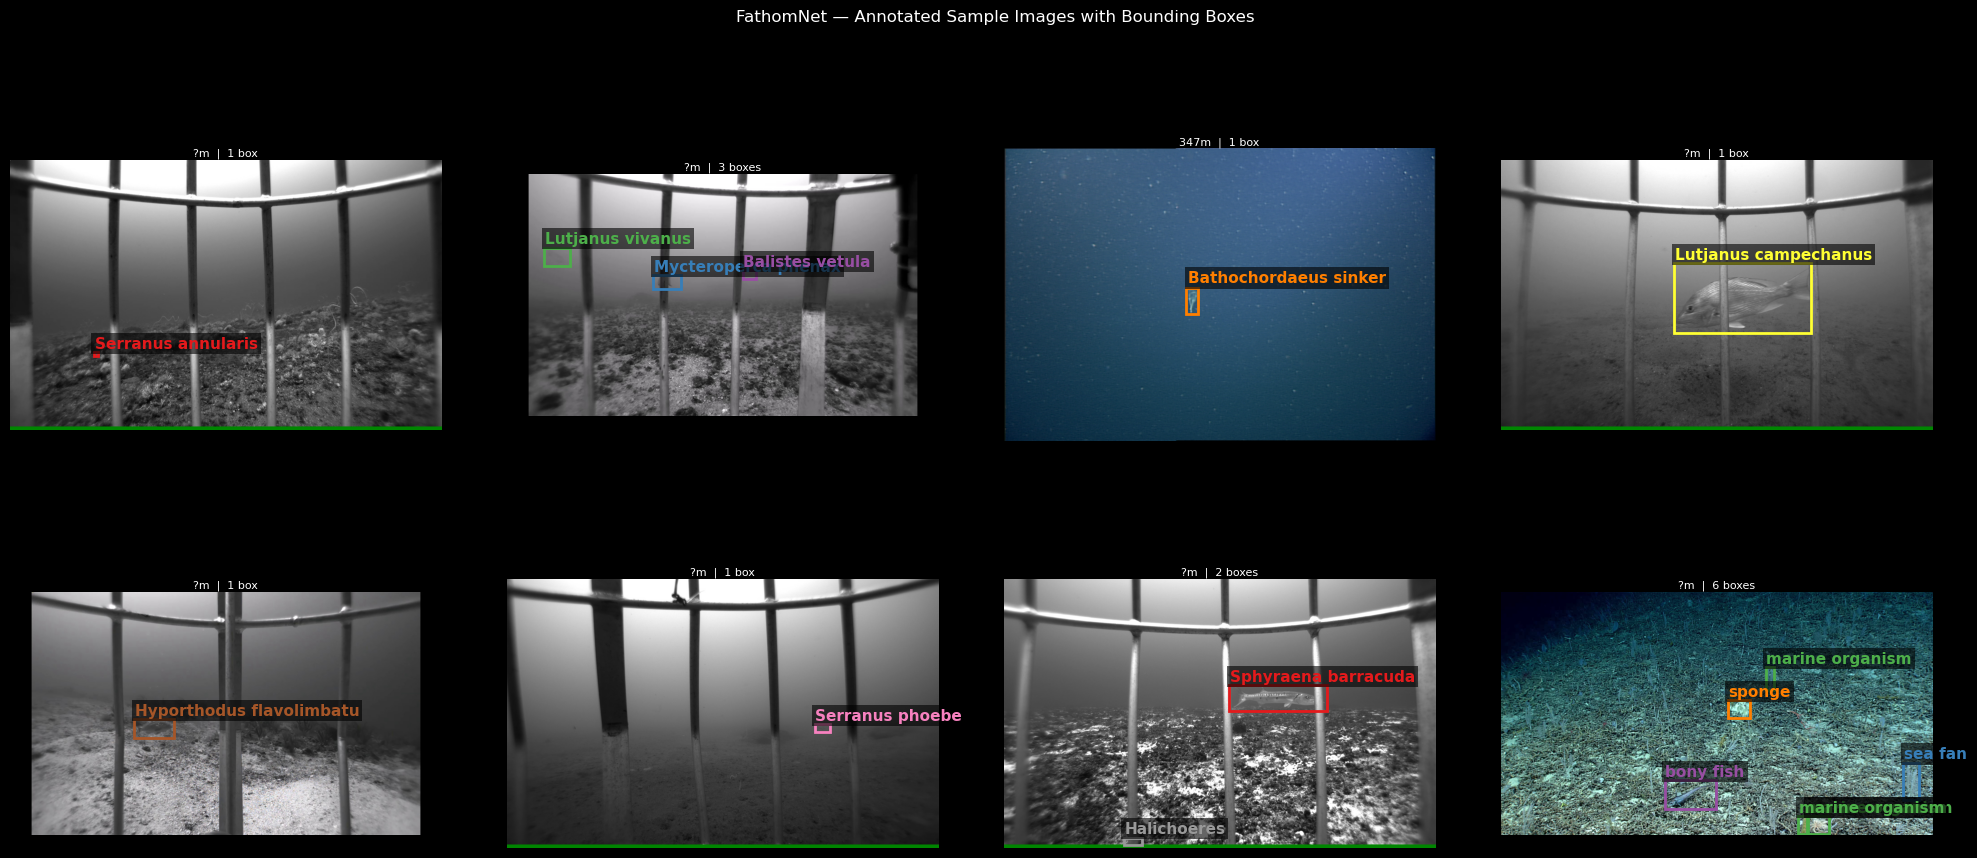

Showing 8 annotated FathomNet images.


In [58]:
# ── FathomNet: annotated image sample with bounding boxes ─────────────────
fn_annotated_imgs = [img for img in fn_sample
                     if getattr(img, 'boundingBoxes', None) and len(img.boundingBoxes) > 0]
print(f'FathomNet images with ≥1 box in sample: {len(fn_annotated_imgs):,} '
      f'of {len(fn_sample):,} ({len(fn_annotated_imgs)/len(fn_sample)*100:.0f}%)')

random.seed(42)
_sel = random.sample(fn_annotated_imgs, min(8, len(fn_annotated_imgs)))

_COLORS = [plt.cm.Set1.colors[i % 9] for i in range(30)]
_concept_color_map = {}
_color_idx = 0

def _concept_color(concept):
    global _color_idx
    if concept not in _concept_color_map:
        _concept_color_map[concept] = _COLORS[_color_idx % len(_COLORS)]
        _color_idx += 1
    return _concept_color_map[concept]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
fig.suptitle('FathomNet — Annotated Sample Images with Bounding Boxes', fontsize=12)

shown = 0
for img_obj in _sel:
    if shown >= len(axes): break
    pil_img = fetch_image(img_obj.url)
    if pil_img is None: continue

    ax = axes[shown]
    ax.imshow(pil_img)
    ax.axis('off')

    W, H = pil_img.size
    for bbox in img_obj.boundingBoxes:
        concept = (getattr(bbox, 'concept', None) or 'Unknown').strip()
        x = getattr(bbox, 'x', 0) or 0
        y = getattr(bbox, 'y', 0) or 0
        w = getattr(bbox, 'width', 0) or 0
        h = getattr(bbox, 'height', 0) or 0
        if max(x, y, w, h) <= 1.0:
            x, y, w, h = x * W, y * H, w * W, h * H

        color = _concept_color(concept)
        rect = mpatches.Rectangle((x, y), w, h,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x + 3, y - 5, concept[:24], fontsize=11, color=color,
                va='bottom', fontweight='bold',
                bbox=dict(boxstyle='square,pad=0.2', fc='black', alpha=0.6, lw=0))

    depth   = getattr(img_obj, 'depthMeters', None)
    n_boxes = len(img_obj.boundingBoxes)
    d_str   = f'{depth:.0f}m' if depth else '?m'
    ax.set_title(f'{d_str}  |  {n_boxes} box{"es" if n_boxes != 1 else ""}', fontsize=8, pad=3)
    shown += 1

for ax in axes[shown:]: ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Showing {shown} annotated FathomNet images.')

In [59]:
# ── SQUIDLE+ annotated image data: build annotation index + fetch media info ──
# Run once. Re-run s5-sq-samples freely to adjust the plot without re-fetching.

_ann_by_media = defaultdict(list)
for _a in sq_ann_sample:
    _pt = _a.get('point')
    if isinstance(_pt, dict) and _pt.get('media_id'):
        _ann_by_media[_pt['media_id']].append(_a)

print(f'Unique media IDs in annotation sample: {len(_ann_by_media):,}')

# Favour images with more annotations, then shuffle for variety
random.seed(7)
_candidate_ids = sorted(_ann_by_media.keys(),
                         key=lambda mid: len(_ann_by_media[mid]), reverse=True)
_selected_ids  = _candidate_ids[:min(20, len(_candidate_ids))]
random.shuffle(_selected_ids)
_selected_ids  = _selected_ids[:8]

# Fetch thumbnail URL + original dimensions for coordinate scaling
_sq_media_info = {}
for _mid in _selected_ids:
    try:
        _m = sq_get(f'/api/media/{_mid}',
                    {'include_columns': ['id', 'path_best_thm', 'path_best',
                                         'width', 'height']})
        _sq_media_info[_mid] = _m
        time.sleep(0.05)
    except Exception as _e:
        print(f'  Could not fetch media {_mid}: {_e}')

print(f'Fetched info for {len(_sq_media_info)} media objects')

Unique media IDs in annotation sample: 129
Fetched info for 8 media objects


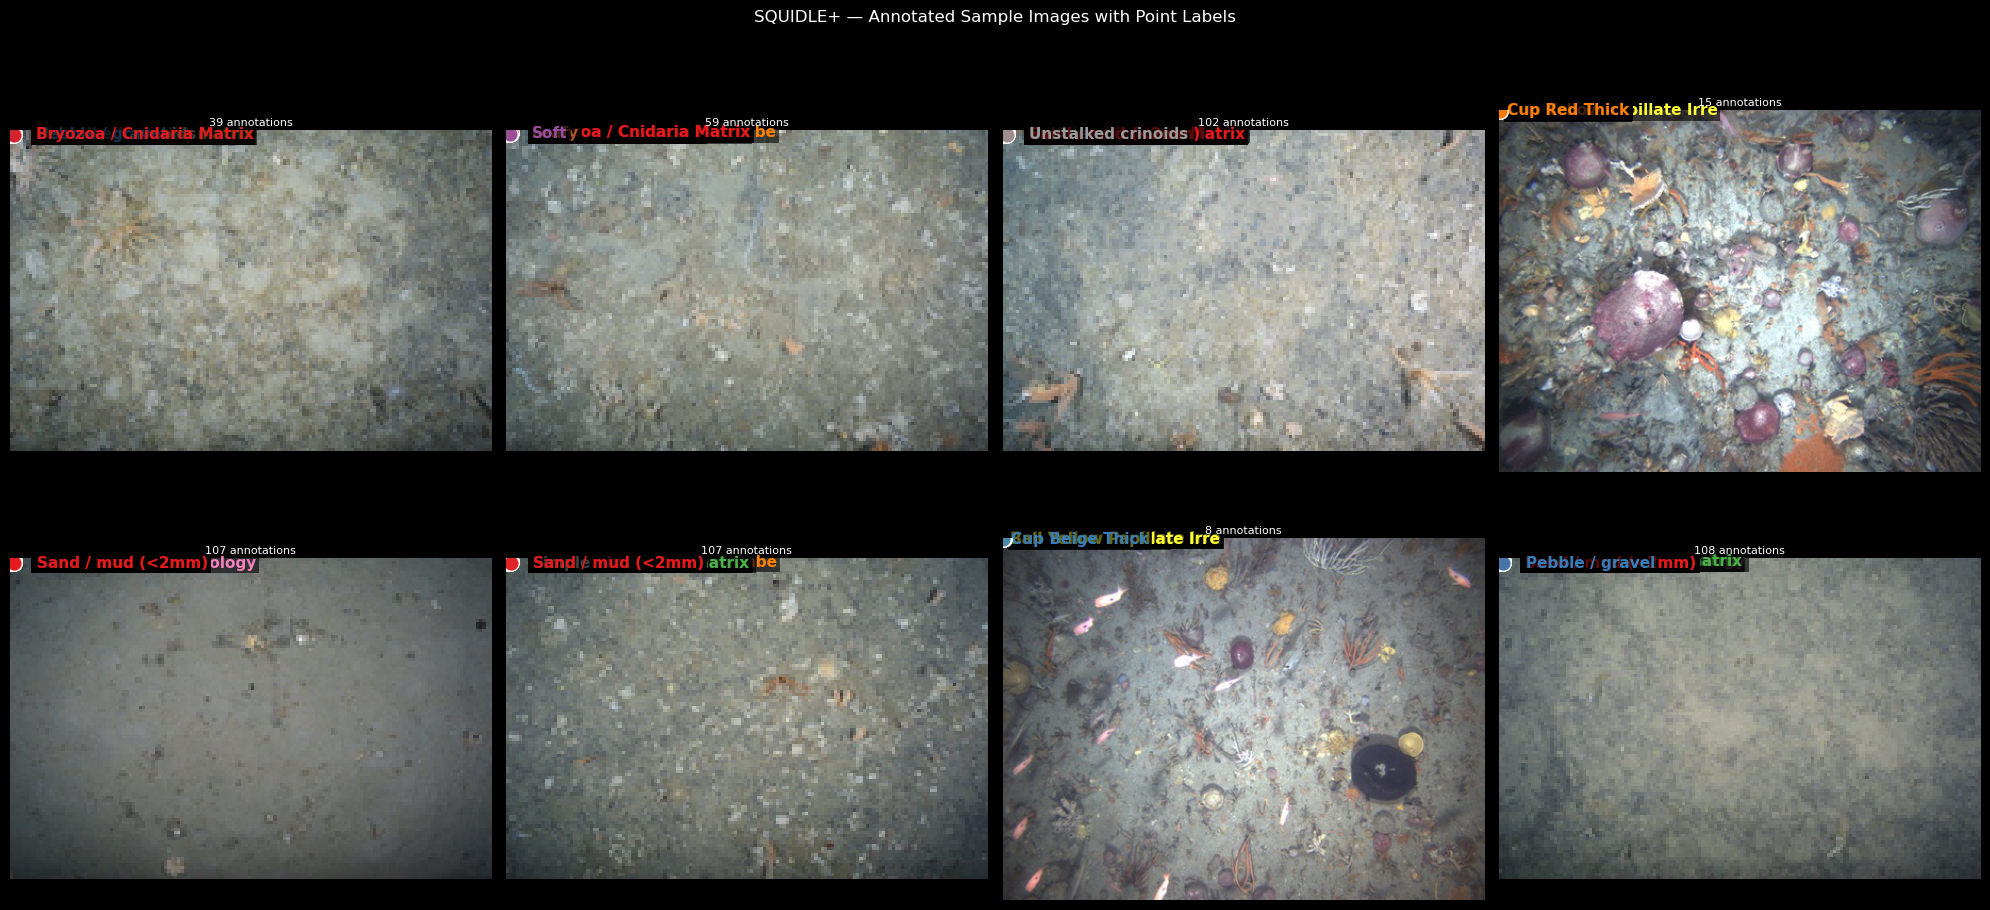

Showing 8 annotated SQUIDLE+ images.


In [60]:
# ── SQUIDLE+: annotated image sample with point label overlays ────────────
# Data from qw9fwkvrbp (_ann_by_media, _selected_ids, _sq_media_info).

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
fig.suptitle('SQUIDLE+ — Annotated Sample Images with Point Labels', fontsize=12)

_sq_concept_color = {}
_sq_color_idx = 0

def _sq_color(concept):
    global _sq_color_idx
    if concept not in _sq_concept_color:
        _sq_concept_color[concept] = _COLORS[_sq_color_idx % len(_COLORS)]
        _sq_color_idx += 1
    return _sq_concept_color[concept]

shown = 0
for _mid in _selected_ids:
    if shown >= len(axes): break
    _m = _sq_media_info.get(_mid)
    if not _m: continue

    _url = _m.get('path_best_thm') or _m.get('path_best', '')
    if not _url: continue
    if not _url.startswith('http'):
        _url = SQ_BASE + _url

    _pil = fetch_image(_url)
    if _pil is None: continue

    ax = axes[shown]
    ax.imshow(_pil)
    ax.axis('off')

    _W, _H = _pil.size
    _img_w = _m.get('width')  or _W
    _img_h = _m.get('height') or _H
    _anns  = _ann_by_media[_mid]

    for _ann in _anns:
        _label_name = (_ann.get('label') or {}).get('name', 'Unknown')
        _pt = _ann.get('point', {})
        _px = _pt.get('x')
        _py = _pt.get('y')
        if _px is None or _py is None:
            continue
        if _px > 1 or _py > 1:
            _px = _px / _img_w * _W
            _py = _py / _img_h * _H

        _color = _sq_color(_label_name)
        ax.plot(_px, _py, 'o', markersize=11, color=_color,
                markeredgecolor='white', markeredgewidth=0.8, alpha=0.9, zorder=5)
        ax.text(_px + 7, _py, _label_name[:26], fontsize=11, color=_color,
                va='center', fontweight='bold',
                bbox=dict(boxstyle='square,pad=0.2', fc='black', alpha=0.6, lw=0))

    ax.set_title(f'{len(_anns)} annotation{"s" if len(_anns) != 1 else ""}', fontsize=8, pad=3)
    shown += 1

for ax in axes[shown:]: ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Showing {shown} annotated SQUIDLE+ images.')

---
## 6. Deployment Synthesis
Building the deployment decision framework from findings 1–5.
**Primary axis: collection type** (AUV / ROV / Diver / Towed / BRUVs / Drop Camera) → then task type → then depth.

| Finding | FathomNet | SQUIDLE+ |
|---|---|---|
| **1. Scale** | 448K images, 1.08M boxes (2.41 boxes/image) | 10.5M images, 6.38M point labels (0.61/image); 25,441 deployments across 32 platforms |
| **2. Platform** | ROV only — 9 institutions; top 3 (NOAA NMFS SEFSC, MBARI, NOAA Ocean Exploration) = 91% of images | AUV (4 platforms), BRUVs (8), Diver (5), Drop Camera (3), ROV (6), Towed (5) — collection type explicit on every deployment |
| **3. Depth** | Median ~866 m (sample); range 3–5,831 m; NE Pacific bias | 94% of deployments shallow (< 100 m); global coverage — 43/72 geographic cells populated |
| **4. Labels** | 2,870 taxa (bounding boxes); extreme long tail — 117 taxa account for 80% of all boxes; top label (*Lutjanus campechanus*) = 14% of all annotations | Substrate-dominant CATAMI hierarchy — Physical/Substrate leads at every level: L0 "Physical" 1.23M, L1 "Substrate" 1.2M, L2 "Unconsolidated (soft)" 1.06M |

> *Values above are a snapshot from a single run; re-execute Section 1 cells to update.*


### Practical Guidance: Choose the Right Database for Your Collection Type

**Primary decision axis: collection type → then task type → then depth.**

---

#### Choose FathomNet when…
- **Platform is ROV** — sole registered imaging type; 9 contributing institutions; minimal domain shift for ROV deployments
- **Task is species / organism detection** — 1.08M bounding boxes, YOLO-ready; no point-label conversion needed
- **Depth > 200 m** — median ~866 m; broadest deep-sea species catalog available (2,870 taxa)

#### Choose SQUIDLE+ when…
- **Platform is AUV** — IMOS Sirius, Nimbus, ACFR Holt give direct domain match; largest AUV image archive globally
- **Platform is Diver or BRUVs** — RLS Diver Photos and 8 BRUV fleets are the dominant SQUIDLE+ contributors by deployment count
- **Task is habitat or substrate classification** — CATAMI labels are substrate-dominant at every taxonomy level; "Substrate" (L1) alone has 1.2M annotations
- **Geographic generalisation needed** — 43/72 global grid cells populated vs FathomNet's NE Pacific concentration
- **Depth < 100 m (coastal/shelf)** — 94% of SQUIDLE+ deployments are shallow; active 2007–2025 with growing coverage each year
